# 📊 Telecom Customer Churn Analysis

This notebook analyzes customer churn data, performs exploratory data analysis (EDA), and builds predictive models.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
pd.set_option('display.max_columns', None)


## 1. Data Import & Initial Exploration

In [2]:
df =  pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
print(f"Rows :  {df.shape[0]} and Coloumns : {df.shape[1]}")

Rows :  7043 and Coloumns : 21


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Data Cleaning & Preprocessing

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.drop(columns="customerID",inplace=True)

## 3. Exploratory Data Analysis (EDA)

### 3.1 Churn Distribution

<Axes: xlabel='Churn'>

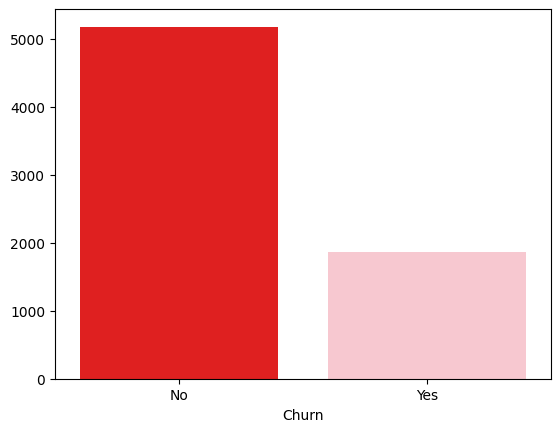

In [7]:
x = df["Churn"].value_counts()
c = ["red","pink"]
sns.barplot(x= x.index,y=x.values,palette=c,hue=x.index)

In [8]:
print(df["TotalCharges"].isnull().sum())
df["TotalCharges"].fillna(df["TotalCharges"].mean(),inplace=True)

11


C:\Users\Zainch-032\AppData\Local\Temp\ipykernel_7628\2725394825.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].mean(),inplace=True)


### 3.2 Key Metrics by Churn Status

In [9]:
df.groupby("Churn")[["MonthlyCharges","TotalCharges","tenure"]].mean()

,MonthlyCharges,TotalCharges,tenure
Churn,,,
No,61.265124,2554.765772,37.569965
Yes,74.441332,1531.796094,17.979133


### 3.3 Tenure Analysis

In [10]:
bins = [0,6,30,50,72]
labels = ["0-6","7-30","31-50","51-72"]
df["ten_bins"] = pd.cut(df["tenure"],bins=bins,labels=labels)
pd.crosstab(df["Churn"],df["ten_bins"])

ten_bins,0-6,7-30,31-50,51-72
Churn,,,,
No,686,1519,1041,1917
Yes,784,641,256,188


### 💡 Key Takeaways: Tenure Analysis

**1. Churn is heavily front-loaded in early tenure — and drops sharply after.**
- In the **0-6 month** bin, the churn rate is **~53%** (more than half leave almost immediately).
- By **51-72 months**, the churn rate is only **~9%**.

*Insight: The first few months are the highest-risk window. Loyalty strongly compounds after that period.*

In [11]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ten_bins
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-6
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,31-50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-6
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,31-50
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-6


### 3.4 Customer Segmentation by Tenure Group

In [12]:
def tenure_based(col):
    if col >= 1 and col <= 8:
        return "New"
    elif col >9 and col < 31:
        return "Established"
    else:
        return "Long Term Customer"
    
df["Tenure_Based_Group"]  = df["tenure"].apply(tenure_based)

df["Tenure_Based_Group"].value_counts()

Tenure_Based_Group
Long Term Customer    3532
Established           1787
New                   1724
Name: count, dtype: int64

### 💡 Key Takeaways: Customer Segmentation

- **New Customers (1-8 months):** Still trialing the service.
- **Established Customers (9-30 months):** Settling in and establishing loyalty.
- **Long Term Customers (30+ months):** Have shown strong commitment to the service.

<Axes: xlabel='total_addons', ylabel='Churn'>

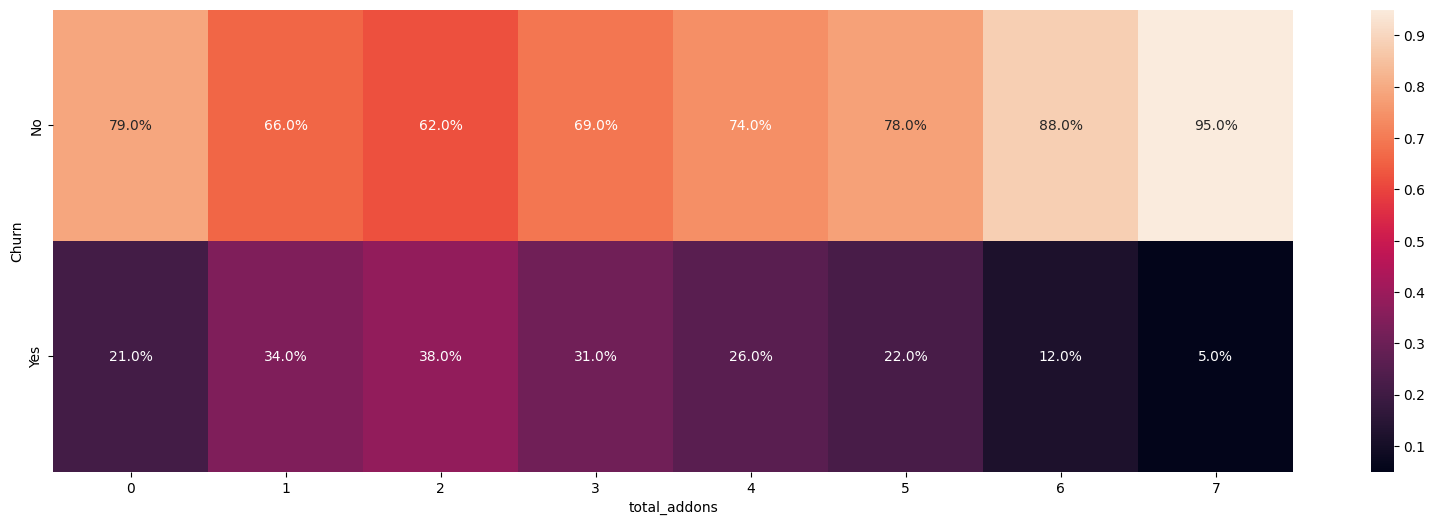

In [13]:
addon_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

def count_addons(row):
    return sum(row[col] == 'Yes' for col in addon_cols)

df['total_addons'] = df.apply(count_addons, axis=1)

x = pd.crosstab(df["Churn"],df["total_addons"],normalize="columns").round(2)

plt.figure(figsize=(20,6))
sns.heatmap(x, annot=True, fmt='.1%')

## 📊 Add-on Services vs Churn Analysis

### Key Insights

**Insight 1: More Add-ons = Less Churn**
Customers with more add-on services churn significantly less — they are deeply 
integrated and get more value from the service.

**Insight 2: Zero Add-ons = Highest Churn Risk**
Customers with 0 add-ons are the most vulnerable — nearly half of them churn. 
They have minimal attachment to the service and can easily switch to a competitor.

### 💡 Business Recommendation
Upsell add-on services to new customers with 0–1 services → reduces churn risk 
significantly. A customer moving from 0 to just 1 add-on drops churn from **44% → 21%**.

C:\Users\Zainch-032\AppData\Local\Temp\ipykernel_7628\204617277.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x.index,y=x.values,palette=["grey","black"])


<Axes: xlabel='Churn'>

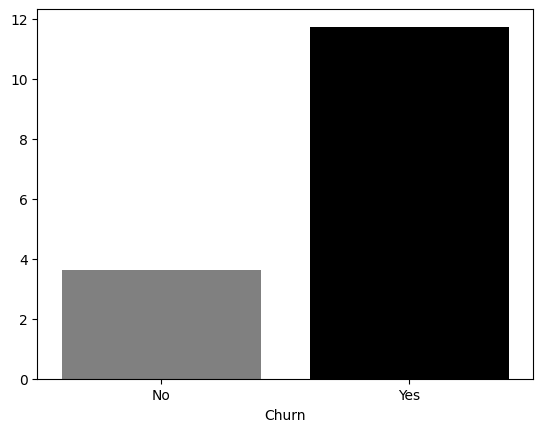

In [14]:
df['charge_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)
x= df.groupby("Churn")["charge_per_tenure"].mean()

sns.barplot(x=x.index,y=x.values,palette=["grey","black"])

## 📊 Charge-per-Tenure vs Churn Analysis

**Insight 1: Churned Customers Have Higher Charge-per-Tenure Ratio**
Customers who churned (Yes) have a significantly higher charge-per-tenure ratio (~12)
compared to retained customers (~3.6) — meaning they were paying more relative to 
how long they stayed, indicating poor value perception.

**Insight 2: Low Tenure + High Charges = Churn Signal**
A high charge-per-tenure ratio reveals customers who left early despite paying 
premium prices — they did not stay long enough to justify the cost, making this 
ratio a strong churn predictor.

## 4. Feature Engineering & Encoding

In [15]:
from sklearn.preprocessing import LabelEncoder

# Binary columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# Ordinal encoding
contract_order = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract'] = df['Contract'].map(contract_order)


# One-Hot encoding (nominal)
nominal_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod',"Tenure_Based_Group"]

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
df.drop(columns=["ten_bins"],inplace=True)

In [16]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,total_addons,charge_per_tenure,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Based_Group_Long Term Customer,Tenure_Based_Group_New
0,0,0,1,0,1,0,0,1,29.85,29.85,0,1,14.925000,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True
1,1,0,0,0,34,1,1,0,56.95,1889.50,0,2,1.627143,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False
2,1,0,0,0,2,1,0,1,53.85,108.15,1,2,17.950000,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True
3,1,0,0,0,45,0,1,0,42.30,1840.75,0,3,0.919565,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False
4,0,0,0,0,2,1,0,1,70.70,151.65,1,0,23.566667,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True


In [17]:
label = LabelEncoder()
for col in df.select_dtypes(include=["boolean","object"]).columns:
    df[col] = label.fit_transform(df[col])
    
    
df.head(4)
df.corr()["Churn"].sort_values(ascending=False)

Churn                                    1.000000
charge_per_tenure                        0.411756
Tenure_Based_Group_New                   0.313755
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                  -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
total_addons                            -0.069533
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448


### 4.1 Feature Selection

In [18]:
drop_cols = ['gender', 'PhoneService', 'MultipleLines_No phone service',"StreamingTV_Yes","StreamingMovies_Yes","MultipleLines_Yes","DeviceProtection_Yes","OnlineBackup_Yes"]
df = df.drop(drop_cols, axis=1)
print("Remaining columns:", df.shape[1])

Remaining columns: 26


### 💡 Key Takeaways: Feature Importance

- **charge_per_tenure (engineered)** is the strongest churn predictor.
- Demographic features (gender) and less impactful services (PhoneService, MultipleLines_No phone service) were dropped to reduce noise.

## 5. Data Scaling

In [19]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Numerical columns that need scaling
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 
            'total_addons', 'charge_per_tenure']

X = df.drop('Churn', axis=1)
y = df['Churn']

# Split FIRST, then scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler
ss = StandardScaler()
X_train_ss = X_train.copy()
X_test_ss = X_test.copy()
X_train_ss[num_cols] = ss.fit_transform(X_train[num_cols])
X_test_ss[num_cols] = ss.transform(X_test[num_cols])  # only transform, never fit

# MinMaxScaler
mm = MinMaxScaler()
X_train_mm = X_train.copy()
X_test_mm = X_test.copy()
X_train_mm[num_cols] = mm.fit_transform(X_train[num_cols])
X_test_mm[num_cols] = mm.transform(X_test[num_cols])

### ℹ️ Best Practice: Data Leakage Prevention

**Why fit the scaler only on the training set?**
To prevent *data leakage*. If we fit the scaler on the entire dataset, information from the test set would influence the scaling parameters (mean/variance), resulting in overly optimistic model evaluation.

## 6. Model Training & Evaluation

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'KNN':                 KNeighborsClassifier(),
    'SVM':                 SVC(probability=True),
    'Naive Bayes':         GaussianNB()
}

results = []

for name, model in models.items():
    model.fit(X_train_ss, y_train)
    y_pred = model.predict(X_test_ss)
    y_prob = model.predict_proba(X_test_ss)[:, 1]

    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.803407   0.664407  0.524064  0.585949  0.844561
3    Gradient Boosting  0.801987   0.661017  0.521390  0.582960  0.844270
6          Naive Bayes  0.683463   0.448424  0.836898  0.583955  0.820246
2        Random Forest  0.776437   0.602076  0.465241  0.524887  0.819151
5                  SVM  0.797729   0.659498  0.491979  0.563553  0.781429
4                  KNN  0.773598   0.583587  0.513369  0.546230  0.776292
1        Decision Tree  0.720369   0.473684  0.481283  0.477454  0.647240
